In [26]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.metrics import classification_report


Numberical Naive bayes

In [27]:

#  Numerical Gaussian Naive Bayes 
class GaussianNB:

    def fit(self, X, y):

        self.classes = np.unique(y)
        self.mean = {}
        self.var = {}
        self.prior = {}

        for c in self.classes:

            X_c = X[y == c]

            self.mean[c] = np.mean(X_c, axis=0)
            self.var[c] = np.var(X_c, axis=0)

            self.prior[c] = len(X_c) / len(X)


    def gaussian(self, class_idx, x):

        mean = self.mean[class_idx]
        var = self.var[class_idx]

        numo= np.exp(-(x-mean)**2 / (2*var))
        deno = np.sqrt(2*np.pi*var)

        return numo/ deno


    def predict(self, X):

        preds = []

        for x in X:

            posteriors = []

            for c in self.classes:

                prior = np.log(self.prior[c])

                likelihood = np.sum(np.log(self.gaussian(c, x)))

                posterior = prior + likelihood

                posteriors.append(posterior)

            preds.append(self.classes[np.argmax(posteriors)])

        return np.array(preds)

Categogrical Naive bayes

In [28]:

class CategoricalNB:

    def fit(self, X, y):

        self.classes = np.unique(y)
        self.prior = {}
        self.likelihood = {}

        for c in self.classes:

            X_c = X[y == c]

            self.prior[c] = len(X_c) / len(X)

            self.likelihood[c] = []

            for col in range(X.shape[1]):

                values, counts = np.unique(X_c[:,col], return_counts=True)

                prob = {}

                for v,count in zip(values,counts):
                    prob[v] = count / len(X_c)

                self.likelihood[c].append(prob)


    def predict(self, X):

        preds = []

        for x in X:

            probs = {}

            for c in self.classes:

                prob = self.prior[c]

                for i,value in enumerate(x):

                    if value in self.likelihood[c][i]:
                        prob *= self.likelihood[c][i][value]
                    else:
                        prob *= 1e-6

                probs[c] = prob

            preds.append(max(probs, key=probs.get))

        return np.array(preds)

PCA

In [29]:
def pca(Data, k):
    Data_mean = Data - np.mean(Data, axis=0)

    covariance_matrix = np.cov(Data_mean,rowvar=False)

    eig_values, eig_vectors = np.linalg.eig(covariance_matrix)

    eign_indexes = np.argsort(eig_values)[::-1]
    eigenvectors_sorted = eig_vectors[:,eign_indexes]

    selected_eigenvectors = eigenvectors_sorted[:, :k]

    transformed_data = np.dot(Data_mean, selected_eigenvectors)

    return transformed_data


In [30]:
df_num = pd.read_csv("survey lung cancer.csv")
df_num.head()

,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN,LUNG_CANCER
0,M,69,1,2,2,1,1,2,1,2,2,2,2,2,2,YES
1,M,74,2,1,1,1,2,2,2,1,1,1,2,2,2,YES
2,F,59,1,1,1,2,1,2,1,2,1,2,2,1,2,NO
3,M,63,2,2,2,1,1,1,1,1,2,1,1,2,2,NO
4,F,63,1,2,1,1,1,1,1,2,1,2,2,1,1,NO


In [31]:
df_num.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 309 entries, 0 to 308
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   GENDER                 309 non-null    object
 1   AGE                    309 non-null    int64 
 2   SMOKING                309 non-null    int64 
 3   YELLOW_FINGERS         309 non-null    int64 
 4   ANXIETY                309 non-null    int64 
 5   PEER_PRESSURE          309 non-null    int64 
 6   CHRONIC DISEASE        309 non-null    int64 
 7   FATIGUE                309 non-null    int64 
 8   ALLERGY                309 non-null    int64 
 9   WHEEZING               309 non-null    int64 
 10  ALCOHOL CONSUMING      309 non-null    int64 
 11  COUGHING               309 non-null    int64 
 12  SHORTNESS OF BREATH    309 non-null    int64 
 13  SWALLOWING DIFFICULTY  309 non-null    int64 
 14  CHEST PAIN             309 non-null    int64 
 15  LUNG_CANCER            

In [32]:
df_num.columns

Index(['GENDER', 'AGE', 'SMOKING', 'YELLOW_FINGERS', 'ANXIETY',
       'PEER_PRESSURE', 'CHRONIC DISEASE', 'FATIGUE ', 'ALLERGY ', 'WHEEZING',
       'ALCOHOL CONSUMING', 'COUGHING', 'SHORTNESS OF BREATH',
       'SWALLOWING DIFFICULTY', 'CHEST PAIN', 'LUNG_CANCER'],
      dtype='object')

In [33]:

df_num['GENDER'] = df_num['GENDER'].map({'M': 0, 'F': 1})
df_num['LUNG_CANCER'] = df_num['LUNG_CANCER'].map({'NO': 0, 'YES': 1})
df_num.head()


,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN,LUNG_CANCER
0,0,69,1,2,2,1,1,2,1,2,2,2,2,2,2,1
1,0,74,2,1,1,1,2,2,2,1,1,1,2,2,2,1
2,1,59,1,1,1,2,1,2,1,2,1,2,2,1,2,0
3,0,63,2,2,2,1,1,1,1,1,2,1,1,2,2,0
4,1,63,1,2,1,1,1,1,1,2,1,2,2,1,1,0


In [34]:
X1 = df_num.drop("LUNG_CANCER",axis=1).values
y1 = df_num["LUNG_CANCER"].values
X_train1, X_test1, y_train1, y_test1 = train_test_split(X1, y1, test_size=0.3, random_state=42)


Gaussian NB (No PCA)

Gaussian Naive Bayes — Original Features (No PCA)
Accuracy: 0.9570

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.57      0.67         7
           1       0.97      0.99      0.98        86

    accuracy                           0.96        93
   macro avg       0.88      0.78      0.82        93
weighted avg       0.95      0.96      0.95        93

Confusion Matrix:
[[ 4  3]
 [ 1 85]]


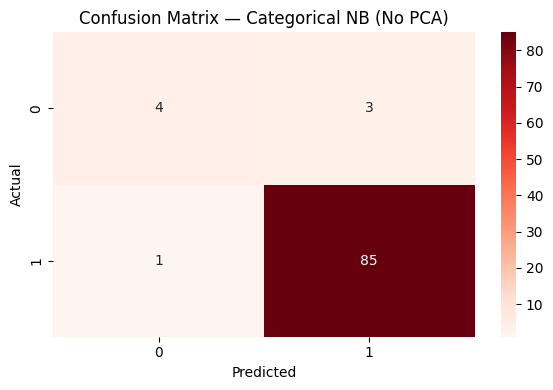

In [35]:
cnb = CategoricalNB()
cnb.fit(X_train1, y_train1)
y_pred_cat = cnb.predict(X_test1)


acc_full = accuracy_score(y_test1, y_pred_cat)
cm_full = confusion_matrix(y_test1, y_pred_cat)
cr_full = classification_report(y_test1, y_pred_cat)

print("=" * 50)
print("Gaussian Naive Bayes — Original Features (No PCA)")
print("=" * 50)
print(f"Accuracy: {acc_full:.4f}")
print("\nClassification Report:")
print(cr_full)
print("Confusion Matrix:")
print(cm_full)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_full, annot=True, fmt="d", cmap="Reds",
            xticklabels=cnb.classes, yticklabels=cnb.classes)
plt.title("Confusion Matrix — Categorical NB (No PCA)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

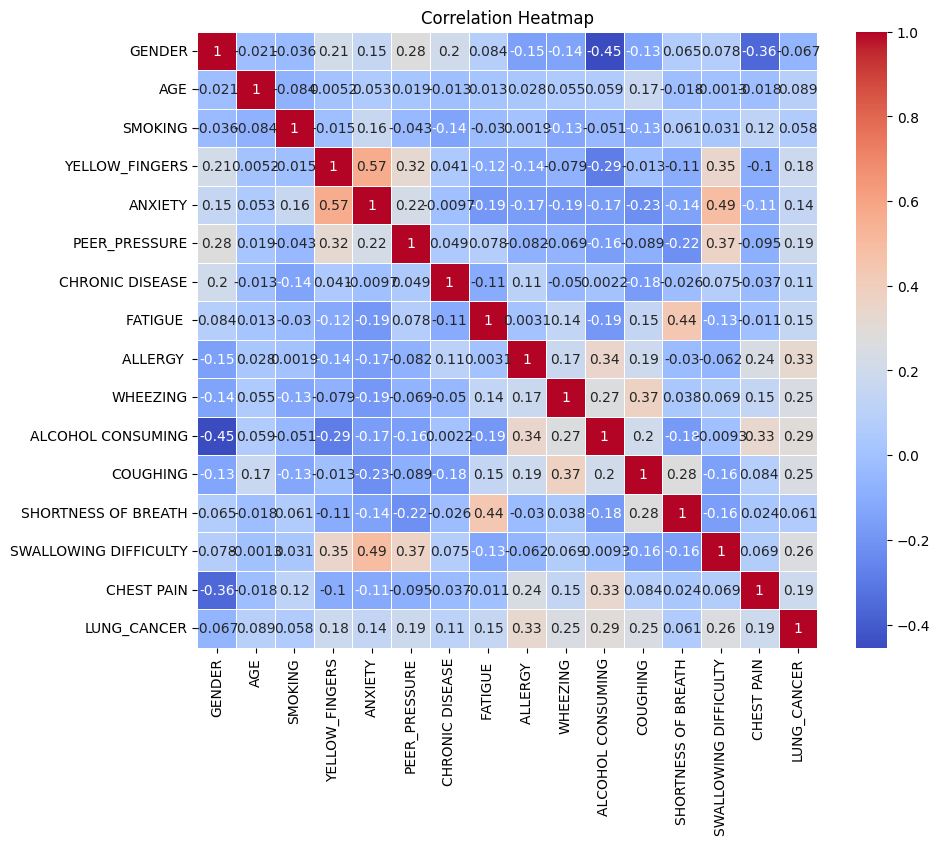

In [36]:
corr_matrix = df_num.corr(numeric_only=True)
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

Feature Selection + Naive Bayes

In [37]:
df_num.columns

Index(['GENDER', 'AGE', 'SMOKING', 'YELLOW_FINGERS', 'ANXIETY',
       'PEER_PRESSURE', 'CHRONIC DISEASE', 'FATIGUE ', 'ALLERGY ', 'WHEEZING',
       'ALCOHOL CONSUMING', 'COUGHING', 'SHORTNESS OF BREATH',
       'SWALLOWING DIFFICULTY', 'CHEST PAIN', 'LUNG_CANCER'],
      dtype='object')

In [38]:

df_cat_selected = df_num[['ALLERGY ','ALCOHOL CONSUMING', 'COUGHING',
                               'SWALLOWING DIFFICULTY','WHEEZING','LUNG_CANCER']]

X2 = df_cat_selected.drop("LUNG_CANCER", axis=1).values
y2 = df_cat_selected["LUNG_CANCER"].values

X_train2, X_test2, y_train2, y_test2 = train_test_split(X2, y2, test_size=0.3, random_state=42)

Categorical Naive Bayes — Selected Features (No PCA)
Accuracy: 0.9355

Classification Report:
              precision    recall  f1-score   support

           0       0.57      0.57      0.57         7
           1       0.97      0.97      0.97        86

    accuracy                           0.94        93
   macro avg       0.77      0.77      0.77        93
weighted avg       0.94      0.94      0.94        93

Confusion Matrix:
[[ 4  3]
 [ 3 83]]


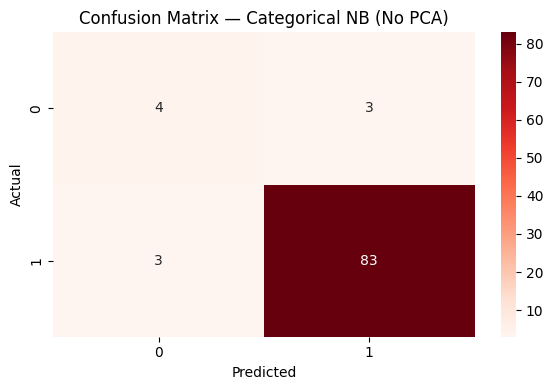

In [39]:
cnb = CategoricalNB()
cnb.fit(X_train2, y_train2)
y_pred_cat = cnb.predict(X_test2)


acc_full = accuracy_score(y_test2, y_pred_cat)
cm_full = confusion_matrix(y_test2, y_pred_cat)
cr_full = classification_report(y_test2, y_pred_cat)

print("=" * 50)
print("Categorical Naive Bayes — Selected Features (No PCA)")
print("=" * 50)
print(f"Accuracy: {acc_full:.4f}")
print("\nClassification Report:")
print(cr_full)
print("Confusion Matrix:")
print(cm_full)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_full, annot=True, fmt="d", cmap="Reds",
            xticklabels=cnb.classes, yticklabels=cnb.classes)
plt.title("Confusion Matrix — Categorical NB (No PCA)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

k=2: Accuracy = 0.9247
k=3: Accuracy = 0.9032
k=4: Accuracy = 0.8925
k=5: Accuracy = 0.8817
k=6: Accuracy = 0.8602
k=7: Accuracy = 0.8710
k=8: Accuracy = 0.8710
k=9: Accuracy = 0.8817
k=10: Accuracy = 0.8710
k=11: Accuracy = 0.8710
k=12: Accuracy = 0.8817
k=13: Accuracy = 0.8925
k=14: Accuracy = 0.8925
k=15: Accuracy = 0.8925


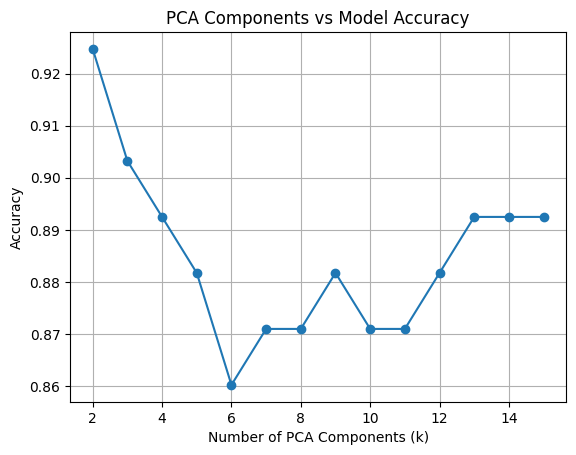

In [40]:
results_pca = []


for k in range(2, X1.shape[1] + 1):
    X_train_pca = pca(X_train1, k)
    X_test_pca = pca(X_test1, k)
    
    gnb_pca = GaussianNB()
    gnb_pca.fit(X_train_pca, y_train1)
    
    y_pred_pca = gnb_pca.predict(X_test_pca)
    
    acc_pca = accuracy_score(y_test1, y_pred_pca)
    
    results_pca.append({
        'k': k,
        'Accuracy': acc_pca
    })
    
    print(f"k={k}: Accuracy = {acc_pca:.4f}")

    

k_values = [r['k'] for r in results_pca]
accuracies = [r['Accuracy'] for r in results_pca]

plt.plot(k_values, accuracies, marker='o')

plt.xlabel("Number of PCA Components (k)")
plt.ylabel("Accuracy")
plt.title("PCA Components vs Model Accuracy")

plt.grid(True)
plt.show()

Numerical dataset

In [41]:
df_num = pd.read_csv("dataR2.csv")
df_num.head()

,Age,BMI,Glucose,Insulin,HOMA,Leptin,Adiponectin,Resistin,MCP.1,Classification
0,48,23.500000,70,2.707,0.467409,8.8071,9.702400,7.99585,417.114,0
1,83,20.690495,92,3.115,0.706897,8.8438,5.429285,4.06405,468.786,0
2,82,23.124670,91,4.498,1.009651,17.9393,22.432040,9.27715,554.697,0
3,68,21.367521,77,3.226,0.612725,9.8827,7.169560,12.76600,928.220,0
4,86,21.111111,92,3.549,0.805386,6.6994,4.819240,10.57635,773.920,0


In [42]:
df_num.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 116 entries, 0 to 115
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             116 non-null    int64  
 1   BMI             116 non-null    float64
 2   Glucose         116 non-null    int64  
 3   Insulin         116 non-null    float64
 4   HOMA            116 non-null    float64
 5   Leptin          116 non-null    float64
 6   Adiponectin     116 non-null    float64
 7   Resistin        116 non-null    float64
 8   MCP.1           116 non-null    float64
 9   Classification  116 non-null    int64  
dtypes: float64(7), int64(3)
memory usage: 9.2 KB


In [43]:
X1 = df_num.drop("Classification",axis=1).values
y1 = df_num["Classification"].values
X_train1, X_test1, y_train1, y_test1 = train_test_split(X1, y1, test_size=0.2, random_state=42)


Gussian NB (NO PCA)

Gaussian Naive Bayes — Original Features (No PCA)
Accuracy: 0.7500

Classification Report:
              precision    recall  f1-score   support

           0       0.69      0.92      0.79        12
           1       0.88      0.58      0.70        12

    accuracy                           0.75        24
   macro avg       0.78      0.75      0.74        24
weighted avg       0.78      0.75      0.74        24

Confusion Matrix:
[[11  1]
 [ 5  7]]


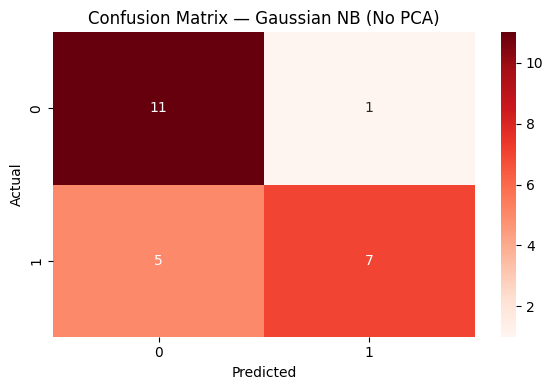

In [44]:
gnb = GaussianNB()
gnb.fit(X_train1, y_train1)
y_pred_cat = gnb.predict(X_test1)


acc_full = accuracy_score(y_test1, y_pred_cat)
cm_full = confusion_matrix(y_test1, y_pred_cat)
cr_full = classification_report(y_test1, y_pred_cat)

print("=" * 50)
print("Gaussian Naive Bayes — Original Features (No PCA)")
print("=" * 50)
print(f"Accuracy: {acc_full:.4f}")
print("\nClassification Report:")
print(cr_full)
print("Confusion Matrix:")
print(cm_full)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_full, annot=True, fmt="d", cmap="Reds",
            xticklabels=gnb.classes, yticklabels=gnb.classes)
plt.title("Confusion Matrix — Gaussian NB (No PCA)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

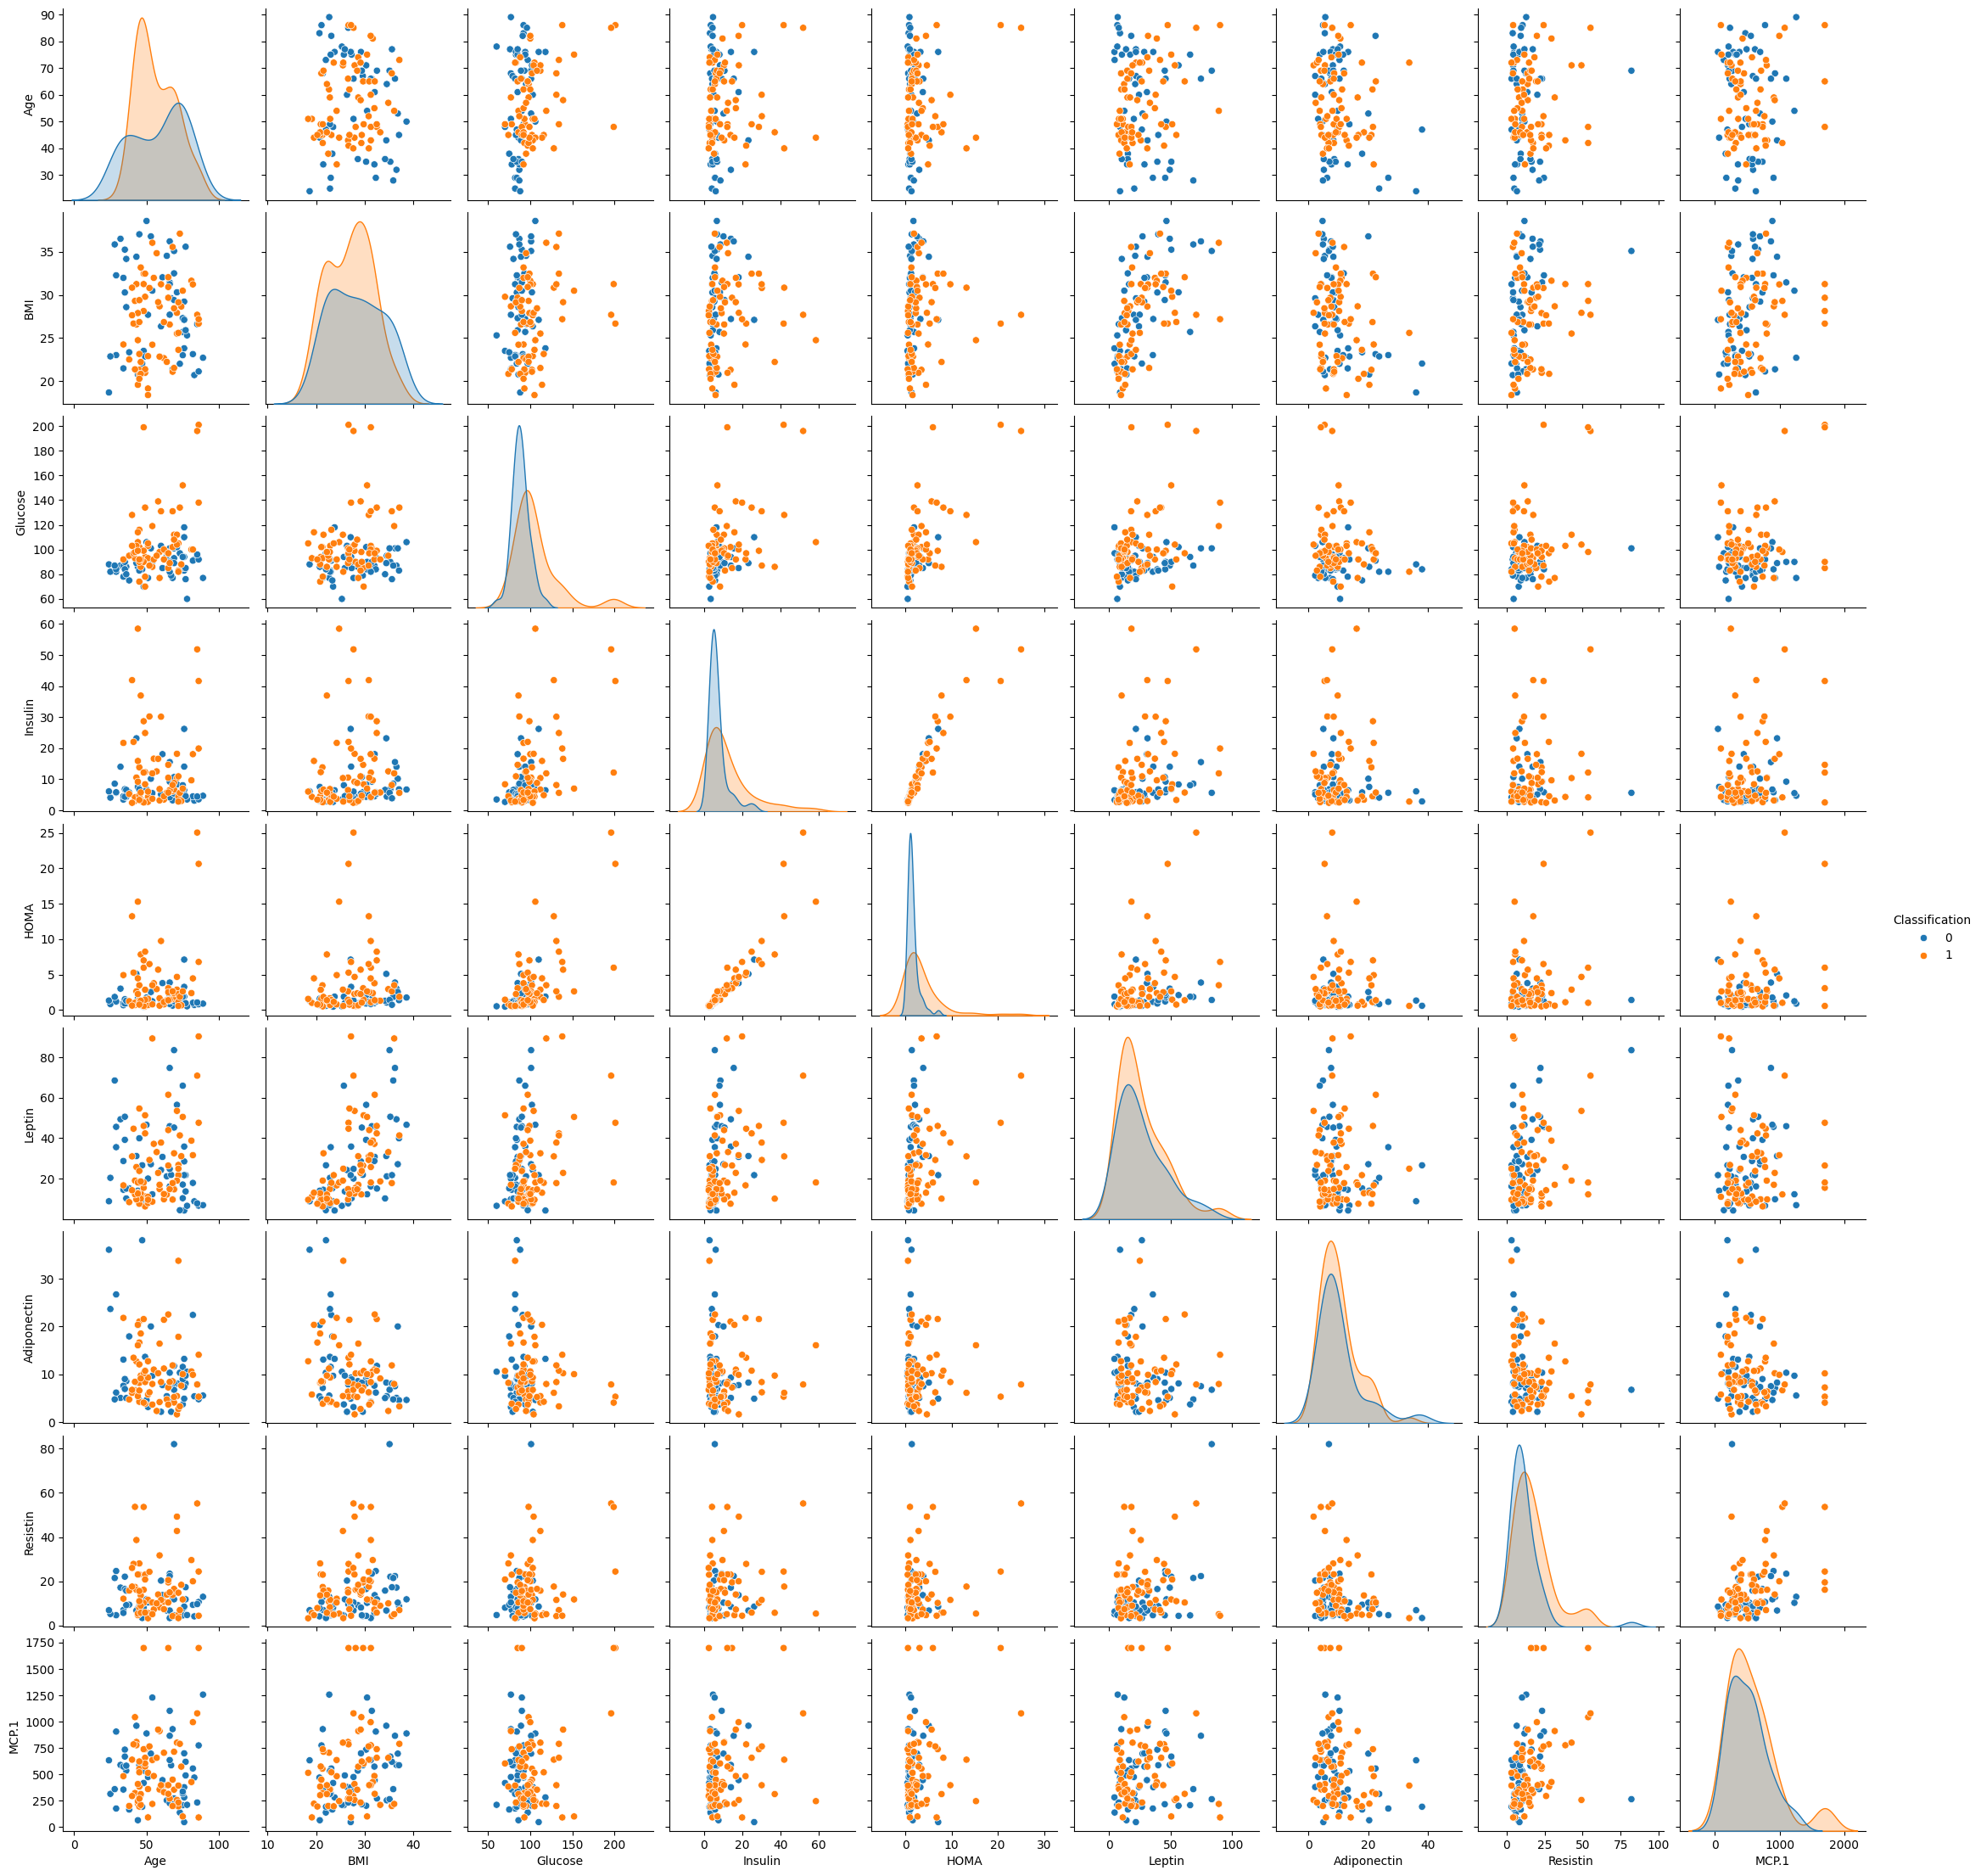

In [45]:
sns.pairplot(df_num, hue="Classification")

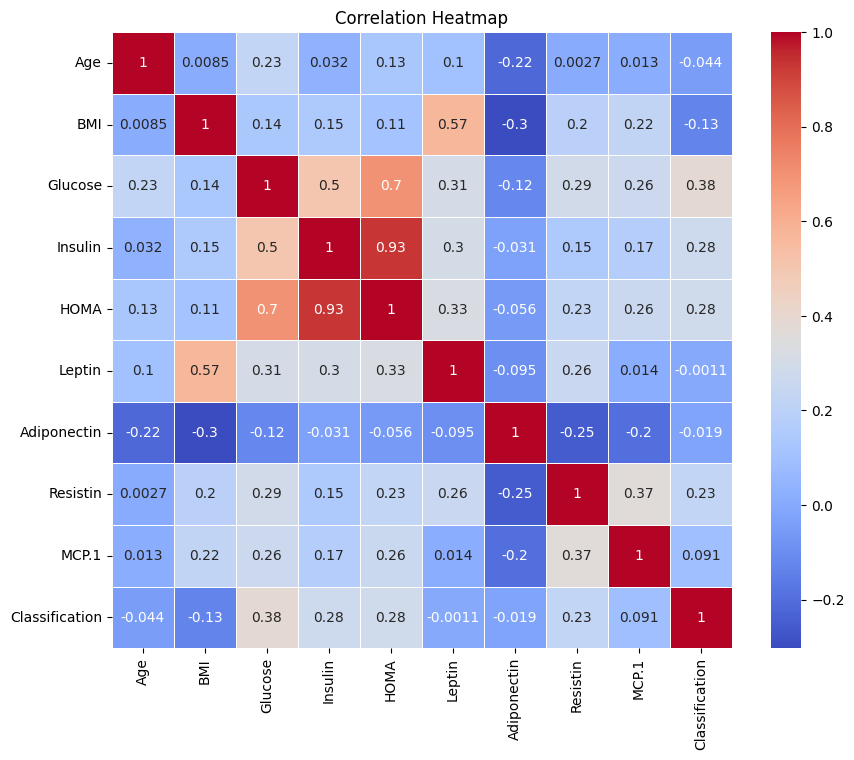

In [46]:
corr_matrix = df_num.corr(numeric_only=True)
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

In [47]:
df_num.columns

Index(['Age', 'BMI', 'Glucose', 'Insulin', 'HOMA', 'Leptin', 'Adiponectin',
       'Resistin', 'MCP.1', 'Classification'],
      dtype='object')

In [48]:

df_num_selected = df_num[['Glucose', 'Insulin', 'HOMA','Leptin','Classification']]

X2 = df_num_selected.drop("Classification", axis=1).values
y2 = df_num_selected["Classification"].values

X_train2, X_test2, y_train2, y_test2 = train_test_split(X2, y2, test_size=0.2, random_state=42)

Categorical Naive Bayes — Selected Features (No PCA)
Accuracy: 0.7083

Classification Report:
              precision    recall  f1-score   support

           0       0.65      0.92      0.76        12
           1       0.86      0.50      0.63        12

    accuracy                           0.71        24
   macro avg       0.75      0.71      0.70        24
weighted avg       0.75      0.71      0.70        24

Confusion Matrix:
[[11  1]
 [ 6  6]]


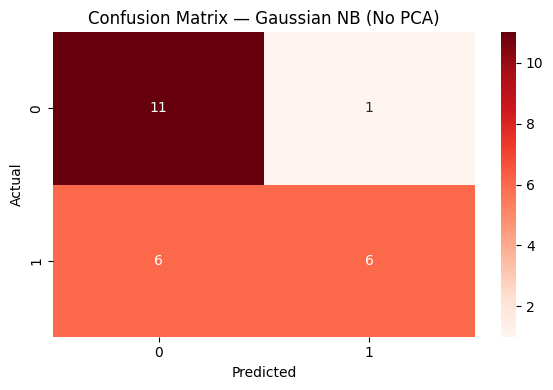

In [49]:
gnb = GaussianNB()
gnb.fit(X_train2, y_train2)
y_pred_cat = gnb.predict(X_test2)


acc_full = accuracy_score(y_test2, y_pred_cat)
cm_full = confusion_matrix(y_test2, y_pred_cat)
cr_full = classification_report(y_test2, y_pred_cat)

print("=" * 50)
print("Categorical Naive Bayes — Selected Features (No PCA)")
print("=" * 50)
print(f"Accuracy: {acc_full:.4f}")
print("\nClassification Report:")
print(cr_full)
print("Confusion Matrix:")
print(cm_full)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_full, annot=True, fmt="d", cmap="Reds",
            xticklabels=gnb.classes, yticklabels=gnb.classes)
plt.title("Confusion Matrix — Gaussian NB (No PCA)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

k=2: Accuracy = 0.7083
k=3: Accuracy = 0.5833
k=4: Accuracy = 0.6250
k=5: Accuracy = 0.6250
k=6: Accuracy = 0.7917
k=7: Accuracy = 0.7917
k=8: Accuracy = 0.6667
k=9: Accuracy = 0.7500


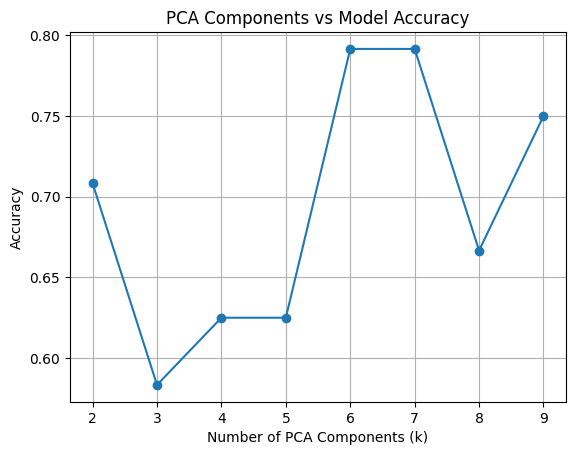

In [50]:
results_pca = []


for k in range(2, X1.shape[1] + 1):
    X_train_pca = pca(X_train1, k)
    X_test_pca = pca(X_test1, k)
    
    gnb_pca = GaussianNB()
    gnb_pca.fit(X_train_pca, y_train1)
    
    y_pred_pca = gnb_pca.predict(X_test_pca)
    
    acc_pca = accuracy_score(y_test1, y_pred_pca)
    
    results_pca.append({
        'k': k,
        'Accuracy': acc_pca
    })
    
    print(f"k={k}: Accuracy = {acc_pca:.4f}")

    

k_values = [r['k'] for r in results_pca]
accuracies = [r['Accuracy'] for r in results_pca]

plt.plot(k_values, accuracies, marker='o')

plt.xlabel("Number of PCA Components (k)")
plt.ylabel("Accuracy")
plt.title("PCA Components vs Model Accuracy")

plt.grid(True)
plt.show()